# CCGT Gas Capex Analysis

Data source: Halcyon Gas Power Plant Tracker (24 Aug 2026), covering gas power plant projects across the US. We keep only CCGT projects with a reported cost ($/kW), then use regression analysis on that data to forecast CCGT capex from 2026 to 2032.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "runreeds.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

FORECAST_DIR = REPO_ROOT / "CEPM/preprocessing/gas_capex_forecast"

df = pd.read_csv(FORECAST_DIR / "Halcyon_August_CCGT.csv")
df.head()

,Plant / Unit Name,State,BA Code,Announcement Date,Planned / Operating Year,Technology Type,Capacity (MW),Cost ($/kW),CapEx ($M),Actual vs. Estimated Cost,Dollar Year,Latitude,Longitude,EIA Status,EIA Plant ID,Dollar Year Used,"Cost ($/kW, 2022$)"
0,Nikiski Combined Cycle (NCC) Repower Project,AK,-,-,2028,Combined-Cycle Gas Turbine,8.0,9625.00,77.0,Estimated,2026,60.67608362,-151.3801804,-,-,2026,8544.04
1,Independence Gas Plant Units 3-6 (IGP 3-6),AR,MISO,"Nov 3, 2025",2030,Combined-Cycle Gas Turbine,1499.0,1741.16,2610.0,Estimated,-,35.67906281,-91.40757611,-,-,2025,1584.26
2,Jefferson Power Station,AR,MISO,"Aug 1, 2025",2029,Combined-Cycle Gas Turbine,754.0,2149.00,1574.0,-,-,34.420068,-92.159813,Regulatory approvals pending. Not under constr...,69185,2025,1955.34
3,Sunridge Power Plant,AZ,AZPS,"Mar 18, 2026",2034,Combined-Cycle Gas Turbine,1360.0,2941.00,4000.0,Estimated,2026,-,-,-,-,2026,2610.70
4,Undesignated CTs P3 - P4,FL,-,-,2034,Combined-Cycle Gas Turbine,400.0,3279.00,1311.6,Estimated,2026,-,-,-,-,2026,2910.74


## Data Cleaning

Drop two types of outliers before fitting:
- Projects with a planned/operating year **after 2032** 
- Projects with a cost **above $3000/kW** 
This leaves 27 CCGT projects to work with.

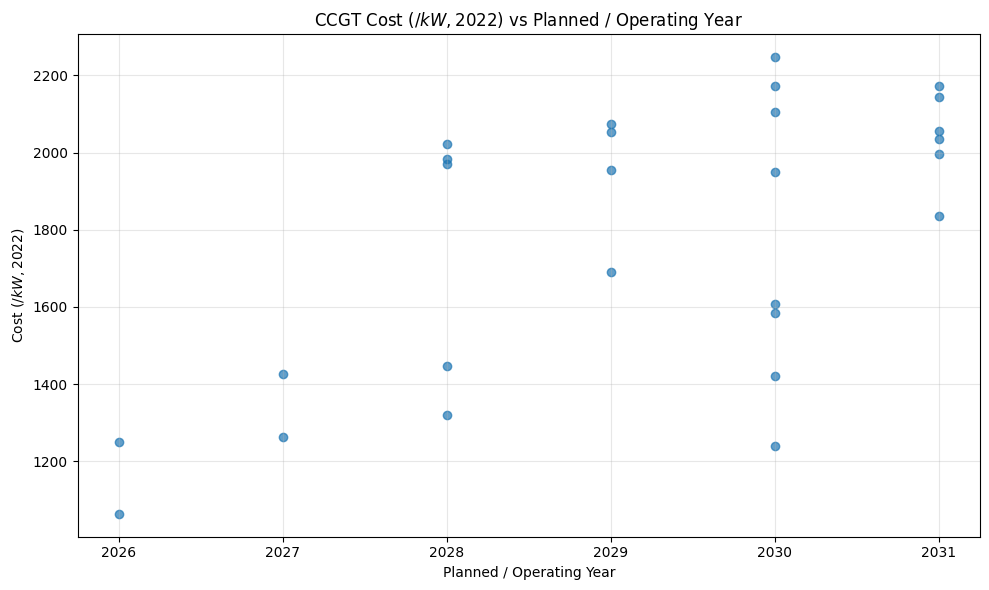

In [2]:
# Use the dollar-year-normalized cost (see data_cleaning_gas.ipynb) instead of the raw, mixed-dollar-year cost
df["Cost ($/kW)"] = pd.to_numeric(df["Cost ($/kW, 2022$)"], errors="coerce")
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Clean data: drop rows with year after 2032 or cost above 3000 $/kW (outliers)
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]
df.shape

# Scatter plot: cost vs year 
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"], alpha=0.7)
ax.set_xlabel("Planned / Operating Year")
ax.set_ylabel("Cost ($/kW, 2022$)")
ax.set_title("CCGT Cost ($/kW, 2022$) vs Planned / Operating Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

years = np.arange(2026, 2033)

Visually, we can see 2 groups of CCGT projects — one below and one above ~$1800/kW. `CCGT_clustering_methods.ipynb` tests several clustering methods (K-Means, hierarchical, DBSCAN) to see whether any of them recover this split in a robust way. Conclusion there: none is satisfactory (the split is largely confounded with operating year, and unstable to small data revisions), so we don't cluster here — we fit a single regression on all the data instead.

## Regression on all data (no clustering)

We fit a single regression on all plants together, with no clustering (see `CCGT_clustering_methods.ipynb` for why clustering isn't used) — this uses the full sample size and directly tests whether cost trends with year across the whole CCGT dataset.


CCGT (all data, no clustering) — 27 plants
  Year  : 2026–2031  (mean 2029.2)
  Cost  : $1064–$2247 /kW, 2022$  (mean $1781, std $357)
  Regression: slope=142.4 $/kW/yr,  R²=0.380,  p=0.001


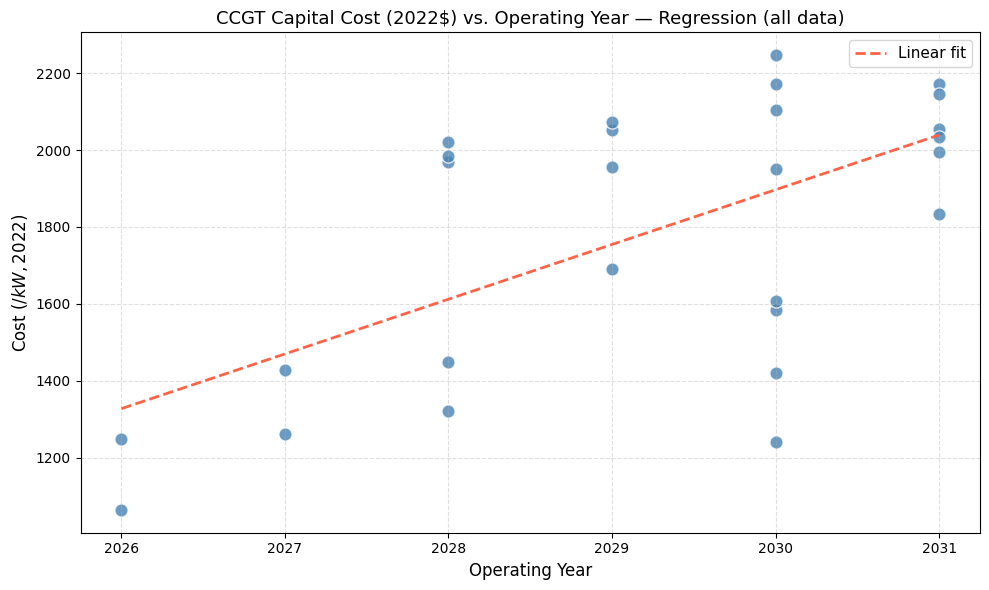

In [3]:
slope_all, intercept_all, r_all, p_all, stderr_all = linregress(df["Planned / Operating Year"], df["Cost ($/kW)"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"],
           color="steelblue", alpha=0.8, edgecolors="white", s=90)

x_range = np.linspace(df["Planned / Operating Year"].min(), df["Planned / Operating Year"].max(), 100)
ax.plot(x_range, intercept_all + slope_all * x_range,
        color="tomato", linewidth=2, linestyle="--", label="Linear fit")

print(f"\nCCGT (all data, no clustering) — {len(df)} plants")
print(f"  Year  : {df['Planned / Operating Year'].min():.0f}–{df['Planned / Operating Year'].max():.0f}  (mean {df['Planned / Operating Year'].mean():.1f})")
print(f"  Cost  : ${df['Cost ($/kW)'].min():.0f}–${df['Cost ($/kW)'].max():.0f} /kW, 2022$  (mean ${df['Cost ($/kW)'].mean():.0f}, std ${df['Cost ($/kW)'].std():.0f})")
print(f"  Regression: slope={slope_all:.1f} $/kW/yr,  R²={r_all**2:.3f},  p={p_all:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW, 2022$)", fontsize=12)
ax.set_title("CCGT Capital Cost (2022$) vs. Operating Year — Regression (all data)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [4]:
# Extract regression statistics (all data)
regression_stats_all = pd.DataFrame([{
    "n_plants": len(df),
    "slope_$/kW_per_yr": slope_all,
    "intercept_$/kW": intercept_all,
    "r_squared": r_all**2,
    "p_value": p_all,
    "std_err": stderr_all,
}])
regression_stats_all

,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,27,142.370089,-287114.362721,0.379589,0.000622,36.402523


- **p-value = 0.001** << 0.05, so this trend **is statistically significant**
- **R² = 0.380** — year explains ~38% of the cost variation; a moderate fit

In [5]:
# Regression forecast 2026-2032 (all data), saved for reuse (e.g. gas_CAPEX_update.ipynb)
forecast_all = pd.DataFrame({
    "Year": years,
    "Cost_$/kW": np.round(intercept_all + slope_all * years, 1),
})
forecast_all.to_csv(FORECAST_DIR / "ccgt_regression_forecast.csv", index=False)
forecast_all

,Year,Cost_$/kW
0,2026,1327.4
1,2027,1469.8
2,2028,1612.2
3,2029,1754.5
4,2030,1896.9
5,2031,2039.3
6,2032,2181.7


Given clustering doesn't hold up (see `CCGT_clustering_methods.ipynb`), we use this single all-data regression as the only CCGT scenario going forward, instead of splitting into low/high-cost cases. `gas_CAPEX_update.ipynb` uses this forecast to update the Gas-CC `capcost` values.